In [1]:
import sys
!{sys.executable} -m pip install -qq pandas torch numpy matplotlib seaborn scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# add more here as needed

### RallyRF  
*Cam Bitter, Sebastian Pantzer, Danny Smith*  
  
Accessible via [this](https://github.com/CamBitter/RallyRF) github repository

**Abstract**

For decades, the sport of Tennis has been meticulously analyzed. Its design naturally lends itself to the development of advanced metrics that serve to reduce complicated gameplay to an interaction of statistics. In this project we aim to take advantage of these metrics to successfully predict outcomes of professional tennis matches. We used an existing database, consisting of the majority of professional tennis matches played since the 1960’s. After cleaning the data, we engineered multiple feature sets of summary statistics based on previous match stats. We trained and tested a Random Forest model on each feature set and compared the results to other models, including another ensemble model--a Gradient-Boosted Decision Tree. In the end, we reached a match prediction accuracy of 63%, while other models reached slightly lower accuracy marks. While our results demonstrate a successful implementation of less complex machine learning algorithms, we are cognizant of potential performance ceilings due to data limitations.

**Introduction:**  
The main motivation behind this project is to learn an more advanced ML technique (that still holds up in modern times) in great detail by building it from the ground up. Random forests are widely popular and effective at medium sized tabular data, and are much more efficient than deep learning models.  

Tennis is a very hard sport to predict, with variables like mental state having huge implications on match outcome. By applying our custom random forest to a real-world prediction problem, we hope to learn about what affects the performance of the model we built and compare our model to research findings.  

The primary source we used was *Random forest model identifies serve strength as a key
predictor of tennis match outcome*, by Zijian Gao and Amanda Kowalczyk. They used the Jeff Sackmann tennis dataset (which we also used, more on that later) and random forests to predict winning outcomes of tennis matches. We followed many of the same procedures and data pipelines as them, in hopes to also gain an accuracy score in the 80% range.  
We also examined the work done in *Tennis Match Prediction using Machine Leanring*, a thesis paper by Ajay Krishna Amudan. Amudan did similar work to Gao and Kowalczyk, but did different work with the data features. We tried integrating elements from both projects in our random forest implementation.
  
Amudan, A. (2019). *Tennis Match Prediction using Machine Leanring*. Stanford University, CS229: Machine Learning. [https://cs229.stanford.edu/proj2019aut/data/assignment_308832_raw/26647696.pdf](https://cs229.stanford.edu/proj2019aut/data/assignment_308832_raw/26647696.pdf)  
  
Gao, Z., & Kowalczyk, A. (2021). Random forest model identifies serve strength as a key predictor of tennis match outcome. *Journal of Sports Analytics*, 7(4), 255–262. [https://doi.org/10.3233/jsa-200515](https://doi.org/10.3233/jsa-200515)

**Values:**  
*Users:*  
This project can and may be used by a range of people, and affect even more. The chief users are likely players/coaches, and gamblers/people who engage in sports betting. Since this project uses information from a large number of tennis players, it is possible to affect those players without their knowledge.  
*Beneficiaries:*  
It is likely the most effective use of this program is in sports betting, so those who benefit most may be people trying to beat conventional odds. However, individual players looking to learn what features and characteristics of play matter most will also be positively affected.  
*Victims:*  
Those negatively affected by this project are parallels of the beneficiaries. - gamblers and players. A powerful prediction tool can both hurt sports bettors without the tool, and give a false sense of security to those who do possess it.  
Additionally, accurate models can harm professional players, who could receive more scrutiny and pressure to perform.  
It is important to note these effects, both positive and negative, are relatively lofty. It is unlikely this specific tool will become popularized enough to have impacts at the scale discussed here.  
*Personal Stake:*  
As a group, we have a few layers of personal connection to this project. Cam is an experienced tennis player, and follows the sport professionally as well as leads the club team at Middlebury. Sebastian, while less involved in tennis, is a member of the track team. Danny plays for the Club Quadball team, and dabbles in other sports, including tennis. Overall, every member of the group has some level of person interest and stake in statistics of athletics. Beyond the sport itself, we all have some academic background in statistics, and were interesting in developing these connections when implementing a Random Forest as a new ML technique.  
*Is the world better off for this project?*  
Realistically, not really. This project has arguably brought engagement in learning to at least the three of us, so in that sense it has had a positive impact. However, the effect may not go beyond that.

**Data**  
Our dataset is [JeffSackmann ATP Data Repository](https://github.com/jeffsackmann/tennis_atp). It contains ATP tennis match results spanning back to 1964, with over 40,000 matches. It is freely available for non-commercial use under a [creative commons license](https://creativecommons.org/licenses/by-nc-sa/4.0/).  
The original dataset has these features:  
```text
tourney_id, tourney_name, surface, draw_size, tourney_level, tourney_date, match_num, 
winner_id, winner_seed, winner_entry, winner_name, winner_hand, winner_ht, winner_ioc, 
winner_age, loser_id, loser_seed, loser_entry, loser_name, loser_hand, loser_ht, 
loser_ioc, loser_age, score, best_of, round, minutes, w_ace, w_df, w_svpt, w_1stIn, 
w_1stWon, w_2ndWon, w_SvGms, w_bpSaved, w_bpFaced, l_ace, l_df, l_svpt, l_1stIn, 
l_1stWon, l_2ndWon, l_SvGms, l_bpSaved, l_bpFaced, winner_rank, winner_rank_points, 
loser_rank, loser_rank_points
```   

Sackmann's data goes all the way back to the 1980s. However, since many of the older matches are incomplete from a statistic tracking perspective, and the style of play in tennis has shifted greatly in the past 30 years, we chose to only look at data from the year 2000 onward. Also, Sackmann keeps track of both doubles and singles matches. We are only using data from singles. Many of these features are *post match* statistics, so we must do some level of data analysis to get stats for a player prior to the match they are competing in. Additionally, per Gao et al., we want to work with difference in player stats. Instead of storing *winner_ht* and *loser_ht*, we can get the same information with *ht_diff*. However, as mentioned before, we also wanted to experiment with not comparing some features. The thought is, the difference between a seed 1 and seed 10 player could be much larger than that between a seed 201 and 210 player. With the large amount of data, sometimes thousands of matches a year, we knew it was not feasible to recalculate the features we wanted every time we ran the models. So, we created three separate files, each with over 120,000 entries:

In [3]:
import pandas as pd

df_all_diffs = pd.read_csv('data/cleaned/all_diffs.csv')
df_some_diffs = pd.read_csv('data/cleaned/some_diffs.csv')
df_no_diffs = pd.read_csv('data/cleaned/no_diffs.csv')

```df_no_diffs```
 contains most of the same features in the original dataset. Note that some features, like the surface type, has been one-hot-encoded:

In [4]:
df_no_diffs.head()

,tourney_id,tourney_date,round,p1_name,p2_name,p1_won,surface_hard,surface_clay,surface_grass,p1_rank,...,p1_second_won,p2_second_won,p1_bp_saved_pct,p2_bp_saved_pct,p1_bp_converted_pct,p2_bp_converted_pct,p1_win_pct,p2_win_pct,p1_games_played,p2_games_played
0,2000-338,20000110,R32,Adrian Voinea,Vincent Spadea,1,1,0,0,102.0,...,0.459459,0.250000,0.800000,0.285714,0.0000,1.000000,0.000000,0.000000,1.0,1.0
1,2000-338,20000110,R32,Daniel Vacek,Jean Rene Lisnard,1,1,0,0,41.0,...,0.260000,0.566265,0.437500,0.761905,0.4000,0.285714,0.500000,0.500000,2.0,2.0
2,2000-338,20000110,R32,Lleyton Hewitt,Sebastien Grosjean,1,1,0,0,21.0,...,0.604651,0.526316,0.708333,0.750000,0.5500,0.750000,1.000000,0.666667,5.0,3.0
3,2000-338,20000110,R32,Slava Dosedel,Mark Woodforde,1,1,0,0,69.0,...,0.560976,0.382353,0.636364,0.687500,0.3750,0.375000,0.500000,0.000000,2.0,1.0
4,2000-301,20000110,R32,Sjeng Schalken,Goran Ivanisevic,1,1,0,0,37.0,...,0.486111,0.542857,0.500000,0.714286,0.3125,1.000000,0.666667,0.000000,3.0,1.0


```df_some_diffs``` has some augmentation. Player seed is still individually tracked:

In [12]:
df_some_diffs.head()

,tourney_id,tourney_date,round,p1_name,p2_name,p1_won,surface_hard,surface_clay,surface_grass,p1_rank,...,age_diff,surface_win_pct_diff,ace_vs_df_diff,first_in_diff,first_won_diff,second_won_diff,bp_saved_pct_diff,bp_converted_pct_diff,win_pct_diff,games_played_diff
0,2000-338,20000110,R32,Adrian Voinea,Vincent Spadea,1,1,0,0,102.0,...,0.0,0.000000,1.400000,0.060928,0.153509,0.209459,0.514286,-1.000000,0.000000,0.0
1,2000-338,20000110,R32,Daniel Vacek,Jean Rene Lisnard,1,1,0,0,41.0,...,8.5,0.000000,0.400000,0.020263,-0.004918,-0.306265,-0.324405,0.114286,0.000000,0.0
2,2000-338,20000110,R32,Lleyton Hewitt,Sebastien Grosjean,1,1,0,0,21.0,...,-2.8,0.333333,-1.444444,0.001931,-0.022631,0.078335,-0.041667,-0.200000,0.333333,2.0
3,2000-338,20000110,R32,Slava Dosedel,Mark Woodforde,1,1,0,0,69.0,...,-4.8,0.500000,-0.333333,0.091800,0.040213,0.178623,-0.051136,0.000000,0.500000,1.0
4,2000-301,20000110,R32,Sjeng Schalken,Goran Ivanisevic,1,1,0,0,37.0,...,-5.0,0.666667,-0.781818,0.021985,0.025253,-0.056746,-0.214286,-0.687500,0.666667,2.0


```df_all_diffs``` joins all features possible. To account for overfitting, and to add more data, we randomly flip rows, switching p1 and p2, and inverting each difference:

In [13]:
df_all_diffs.head()

,tourney_id,tourney_date,surface,round,p1_name,p2_name,p1_won,surface_hard,surface_clay,surface_grass,...,height_diff,surface_win_pct_diff,ace_vs_df_diff,first_in_diff,first_won_diff,second_won_diff,bp_saved_pct_diff,bp_converted_pct_diff,win_pct_diff,games_played_diff
0,2000-338,20000110,Hard,R32,Adrian Voinea,Vincent Spadea,1,1,0,0,...,2.0,0.000000,1.400000,0.060928,0.153509,0.209459,0.514286,-1.000000,0.000000,0.0
1,2000-338,20000110,Hard,R32,Daniel Vacek,Jean Rene Lisnard,1,1,0,0,...,17.0,0.000000,0.400000,0.020263,-0.004918,-0.306265,-0.324405,0.114286,0.000000,0.0
2,2000-338,20000110,Hard,R32,Lleyton Hewitt,Sebastien Grosjean,1,1,0,0,...,5.0,0.333333,-1.444444,0.001931,-0.022631,0.078335,-0.041667,-0.200000,0.333333,2.0
3,2000-338,20000110,Hard,R32,Slava Dosedel,Mark Woodforde,1,1,0,0,...,-5.0,0.500000,-0.333333,0.091800,0.040213,0.178623,-0.051136,0.000000,0.500000,1.0
4,2000-301,20000110,Hard,R32,Sjeng Schalken,Goran Ivanisevic,1,1,0,0,...,0.0,0.666667,-0.781818,0.021985,0.025253,-0.056746,-0.214286,-0.687500,0.666667,2.0


To support our original motivation, we can visualize how often the higher seed player wins the match:

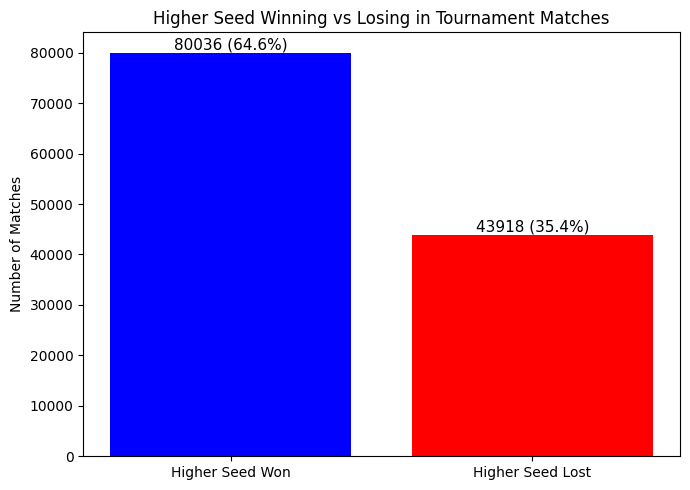

In [5]:
higher_seed_wins = (df_no_diffs['p1_rank'] < df_no_diffs['p2_rank']) & (df_no_diffs['p1_won'] == 1) | \
                   (df_no_diffs['p2_rank'] < df_no_diffs['p1_rank']) & (df_no_diffs['p1_won'] == 0)

counts = higher_seed_wins.value_counts()
labels = ['Higher Seed Won', 'Higher Seed Lost']
values = [counts.get(True, 0), counts.get(False, 0)]
total = sum(values)
bar_labels = [f"{v} ({v/total*100:.1f}%)" for v in values]

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, values, color=['blue', 'red'])


for bar, val, label in zip(bars, values, bar_labels):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
             label, ha='center', va='bottom', fontsize=11)

plt.title('Higher Seed Winning vs Losing in Tournament Matches')
plt.ylabel('Number of Matches')
plt.tight_layout()
plt.show()

As we can see, although the higher seed wins more, with this dataset predicting only on seed is accurate jut 64% of the time. So, our baseline to beat in our prediction is 0.64 accuracy.

**Our Approach**  

Our project centered around the implementation of a random forest. However, we created a logistic regression model, as well as a gradient boosted decision tree, to compare with our random forest, as well as our chosen benchmark. As discussed above, we used three separate (but quite similar) datasets, each with some way to represent the same information. We used the  p1_won variable as our target. p1_won is an indicator variable that outputs 1 if the player denoted as player 1 won the match. It is worth noting that the feature set purely containing differences in previous match stats essentially has twice the observations, where there are two rows corresponding to each match, where one reflects the winner’s result, and the other reflects the loser’s result. While we did this in an effort to provide our models with potentially stronger data with a better signal, we recognize this breach in independence between observations.

When training our models, we used a test-train split that considered the time-sensitive nature of our data. If we had simply randomly selected 80% of the data to train on and kept the remaining 20% to test on, we would run into a data leakage problem. The goal of this project is to make predictions for future matches based on the past. Training our models on a match from 2017 and then testing them on a match from 2009 does not help us reach our goal. Thus, we decided to train on all matches before 2022, and then test on 2022 and beyond.

Our implementation of a random forest model was essentially an ensemble of decision trees, each with bootstrapped data and a random sample of features. The motivation behind this is the idea that a specific decision tree with boostrapped data and a random subset of features might be able to pick up on signals that a decision tree with a different subset of data and features wouldn’t. The random forest makes its prediction by polling each of the different decision trees and going with the outcome that receives the most votes. We can associate a metric of confidence with each prediction of an observation, which is defined as the proportion of trees in the random forest that agree with the winning decision. A confidence score of 0.51 describes a prediction where the different trees were very divided in making their decision as a whole. We used the following parameters of the model: number of trees, maximum-depth of each tree, and maximum amount of features used. Tuning these parameters involves a balancing between underfitting, overfitting, and runtime complexity.



In [6]:
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.random_forest import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier as SklearnRF
from src.features import FEATURE_SETS
from src.decision_tree import DecisionTree

verbose = True 
use_sklearn = False
# Input feature set from data/cleaned/*.csv, defined in features.py
feature_set = "all_diffs.csv"
FEATURE_COLS = FEATURE_SETS[feature_set]
df = pd.read_csv(f"data/cleaned/{feature_set}")

"""
***RESULTS***

all_diffs.csv:
Train accuracy: 86.31%
Test accuracy:  63.48%
Mean confidence: 69.7%

no_diffs.csv:
Train accuracy: 96.35%
Test accuracy:  62.87%
Mean confidence: 62.00%

some_diffs.csv:
Train accuracy: 91.79%
Test accuracy:  63.13%
Mean confidence: 66.24%

"""

# Split by date to avoid leakage — train on pre-2022, test on 2022+
date_split = 20220101

train_df = df[df["tourney_date"] < date_split]
test_df  = df[df["tourney_date"] >= date_split]

X_train = train_df[FEATURE_COLS].to_numpy()
Y_train = train_df["p1_won"].to_numpy()

X_test  = test_df[FEATURE_COLS].to_numpy()
Y_test  = test_df["p1_won"].to_numpy()

print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")
print(f"Features: {len(FEATURE_COLS)}")

n_trees = 10
max_depth = 5
max_features = 10

if use_sklearn:
    print("\nUsing sklearn RandomForestClassifier...")
    forest = SklearnRF(
        n_estimators=n_trees,
        max_depth=max_depth,
        max_features="sqrt",
        random_state=99,
        verbose=1 if verbose else 0,
        n_jobs=-1,
    )
    Y_train_fit = Y_train
else:
    print("\nUsing custom RandomForestClassifier...")
    forest = RandomForestClassifier(
        num_trees=n_trees,
        num_features=max_features,
        max_depth=max_depth,
        random_state=99,
        verbose=verbose,
    )
    Y_train_fit = Y_train.reshape(-1, 1)

print("Fitting...")
t0 = time.time()
forest.fit(X_train, Y_train_fit)
print(f"Fit done in {time.time() - t0:.3f}s")


t1 = time.time()

# print(f"Inference done in {time.time() - t1:.3f}s")

if use_sklearn:
    Y_train_pred = forest.predict(X_train)
else:
    Y_train_pred, _ = forest.predict(X_train)


if use_sklearn:
    Y_pred = forest.predict(X_test)
    Y_confidence = np.max(forest.predict_proba(X_test), axis=1)
else:
    Y_pred, Y_confidence = forest.predict(X_test)
    for t in range(6):
        tree_feature_names = [FEATURE_COLS[i] for i in forest.tree_features[t]]
        # forest.trees[t].print_tree(feature_names=tree_feature_names)

train_accuracy = (Y_train_pred == Y_train).sum() / len(Y_train)
accuracy = (Y_pred == Y_test).sum() / len(Y_test)
print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Test accuracy:  {accuracy:.4f}")
print(f"Gap:            {train_accuracy - accuracy:.4f}")
print("Min confidence:", Y_confidence.min())
print("Max confidence:", Y_confidence.max())
print("Mean confidence:", Y_confidence.mean())





Train: 108526 rows | Test: 15428 rows
Features: 16

Using custom RandomForestClassifier...
Fitting...
  fitting tree 1/10...
  fitting tree 2/10...
  fitting tree 3/10...
  fitting tree 4/10...
  fitting tree 5/10...
  fitting tree 6/10...
  fitting tree 7/10...
  fitting tree 8/10...
  fitting tree 9/10...
  fitting tree 10/10...
Fit done in 3.176s
Train accuracy: 0.6602
Test accuracy:  0.6362
Gap:            0.0239
Min confidence: 0.5
Max confidence: 1.0
Mean confidence: 0.9165672802696395


We can even examine any specific tree in the model, to see what features it splits on, and therefore what has the largest effect on the outcome of the match. 

In [9]:
import io
from contextlib import redirect_stdout

f = io.StringIO()
with redirect_stdout(f):
    tree_idx = 0
    tree_feature_names = [FEATURE_COLS[i] for i in forest.tree_features[tree_idx]]
    forest.trees[tree_idx].print_tree(feature_names=tree_feature_names)

tree_lines = f.getvalue().split('\n')

truncated_tree = '\n'.join(tree_lines[:25])

print(f"tree structure - top 25 lines of tree {tree_idx}:\n")
print(truncated_tree)
print("... [Tree continues] ...")

tree structure - top 25 lines of tree 0:

├── rank_pts_diff <= -51.000  (gain: 0.0448)
│   ├── surface_win_pct_diff <= -0.132  (gain: 0.0137)
│   │   ├── rank_pts_diff <= -1426.000  (gain: 0.0092)
│   │   │   ├── rank_pts_diff <= -3377.000  (gain: 0.0046)
│   │   │   │   ├── surface_win_pct_diff <= -0.277  (gain: 0.0035)
│   │   │   │   │   ├── rank_pts_diff <= -5273.000  (gain: 0.0019)
│   │   │   │   │   │   └── [0.0]
│   │   │   │   │   │   └── [0.0]
│   │   │   │   │   └── surface_win_pct_diff <= -0.275  (gain: 0.0039)
│   │   │   │   │       └── [1.0]
│   │   │   │   │       └── [0.0]
│   │   │   │   └── first_won_diff <= -0.094  (gain: 0.0029)
│   │   │   │       ├── rank_pts_diff <= -1490.000  (gain: 0.0060)
│   │   │   │       │   └── [0.0]
│   │   │   │       │   └── [0.0]
│   │   │   │       └── bp_converted_pct_diff <= 0.097  (gain: 0.0029)
│   │   │   │           └── [0.0]
│   │   │   │           └── [1.0]
│   │   │   └── rank_pts_diff <= -767.000  (gain: 0.0027)
│   │   │ 

Additionally, we can look at all the trees, and see what they each split on first, to help determine what are the most influential features:

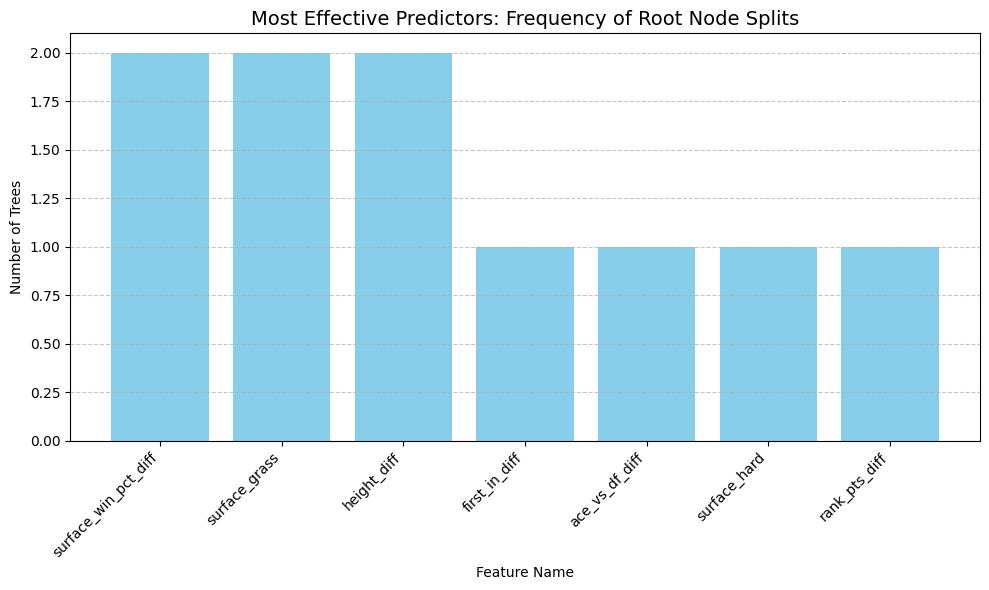

In [49]:
# Base rate: predict p1 wins if they have a lower (better) rank number
if "rank" in FEATURE_COLS:
    rank_baseline = (test_df["rank_diff"] < 0).astype(int).to_numpy()
    baseline_accuracy = (rank_baseline == Y_test).sum() / len(Y_test)
    print(f"Rank baseline: {baseline_accuracy:.4f}")

root_features = []
for tree in forest.trees:
    feature_idx = tree.root.feature
    feature_name = FEATURE_COLS[feature_idx]
    root_features.append(feature_name)

from collections import Counter
counts = Counter(root_features)

plt.figure(figsize=(10, 6))
plt.bar(counts.keys(), counts.values(), color='skyblue')

plt.title('Most Effective Predictors: Frequency of Root Node Splits', fontsize=14)
plt.xlabel('Feature Name')
plt.ylabel('Number of Trees')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.boosted_tree import BoostedTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier as SklearnGB
from src.features import FEATURE_SETS
from src.decision_tree import DecisionTree

verbose = True 
use_sklearn = False
# Input feature set from data/cleaned/*.csv, defined in features.py
feature_set = "some_diffs.csv"
FEATURE_COLS = FEATURE_SETS[feature_set]
df = pd.read_csv(f"data/cleaned/{feature_set}")

"""
***RESULTS***

all_diffs.csv:
Train accuracy: 64.92
Test accuracy:  62.80
Mean confidence: 23.66%

no_diffs.csv:
Train accuracy: 62.87%
Test accuracy:  59.99%
Mean confidence: 26.14%

some_diffs.csv:
Train accuracy: 64.91%
Test accuracy:  62.25%
Mean confidence: 21.19%

"""

# Split by date to avoid leakage — train on pre-2022, test on 2022+
date_split = 20220101

train_df = df[df["tourney_date"] < date_split]
test_df  = df[df["tourney_date"] >= date_split]

X_train = train_df[FEATURE_COLS].to_numpy()
Y_train = train_df["p1_won"].to_numpy()

X_test  = test_df[FEATURE_COLS].to_numpy()
Y_test  = test_df["p1_won"].to_numpy()

print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")
print(f"Features: {len(FEATURE_COLS)}")

n_trees = 10
max_depth = 5

if use_sklearn:
    print("\nUsing sklearn GradientBoostingClassifier...")
    boost = SklearnGB(
        n_estimators=n_trees,
        max_depth=max_depth,
        random_state=99,
        verbose=1 if verbose else 0,
        n_jobs=-1,
    )
    Y_train_fit = Y_train
else:
    print("\nUsing custom BoostedTreeClassifier...")
    boost = BoostedTreeClassifier(
        num_trees=n_trees,
        learning_rate=0.25,
        max_depth=max_depth,
        random_state=41,
        verbose=verbose,
    )
    Y_train_fit = Y_train.reshape(-1, 1)

print("Fitting...")
t0 = time.time()
boost.fit(X_train, Y_train_fit)
print(f"Fit done in {time.time() - t0:.3f}s")


t1 = time.time()

# print(f"Inference done in {time.time() - t1:.3f}s")

if use_sklearn:
    Y_train_pred = boost.predict(X_train)
else:
    Y_train_pred, _, _ = boost.predict(X_train)


if use_sklearn:
    Y_pred = boost.predict(X_test)
    Y_confidence = np.max(boost.predict_proba(X_test), axis=1)
else:
    Y_pred, Y_confidence, tree_preds = boost.predict(X_test)

train_accuracy = (Y_train_pred == Y_train).sum() / len(Y_train)
accuracy = (Y_pred == Y_test).sum() / len(Y_test)
print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Test accuracy:  {accuracy:.4f}")
print("Min confidence:", Y_confidence.min())
print("Max confidence:", Y_confidence.max())
print("Mean confidence:", Y_confidence.mean())

##SHOULD THIS BE IN RESULTS?
Finally, we can look at a confusion matrix to evaluate the model

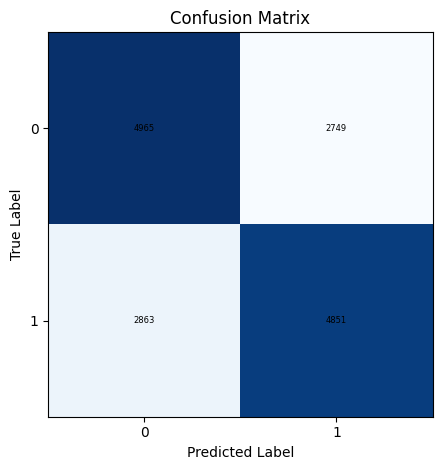

In [39]:
conf_mat = np.zeros((2, 2), dtype=int)
for true, pred in zip(Y_test, Y_pred):
    conf_mat[int(true), int(pred)] += 1

fig, ax = plt.subplots()
im = ax.imshow(conf_mat, cmap="Blues", origin="upper")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["0", "1"])
ax.set_yticklabels(["0", "1"])
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

for i in range(conf_mat.shape[0]):
    for j in range(conf_mat.shape[1]):
        ax.text(j, i, conf_mat[i, j].item(), ha="center", va="center", color="black", size=6)

ax.set_title("Confusion Matrix")
ax.grid(False)
plt.tight_layout()
plt.show()

In addition to the random forest, we created 3 other models. First, we made a logistic regression, to serve as a marginally more complex baseline:

In [17]:
import torch
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from src.features import FEATURE_SETS

from src.log_regression import BinaryLogisticRegression, GradientDescentOptimizer, binary_cross_entropy

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

feature_set = "all_diffs.csv"
FEATURE_COLS = FEATURE_SETS[feature_set]
df = pd.read_csv(f"data/cleaned/{feature_set}")

train_df = df[df["tourney_date"] < 20220101]
test_df  = df[df["tourney_date"] >= 20220101]

X_train = train_df[FEATURE_COLS].to_numpy()
Y_train = train_df["p1_won"].to_numpy()
X_test  = test_df[FEATURE_COLS].to_numpy()
Y_test  = test_df["p1_won"].to_numpy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

device = get_device()
print(f"Training logistic regression on {device}")

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32).unsqueeze(1).to(device)


model = BinaryLogisticRegression(X_train_tensor.shape[1])
model.w = model.w.to(device)
opt = GradientDescentOptimizer(model, lr=0.0001)

# 6. training loop - simplified for the demo
batch_size = 128
n_samples = X_train_tensor.shape[0]
n_epochs = 100
losses = []

print("Fitting Logistic Regression...")
for epoch in range(n_epochs):
    perm = torch.randperm(n_samples, device=device)
    X_shuffled = X_train_tensor[perm]
    Y_shuffled = Y_train_tensor[perm]

    epoch_loss = 0.0
    num_batches = 0

    for start in range(0, n_samples, batch_size):
        X_batch = X_shuffled[start : start + batch_size]
        y_batch = Y_shuffled[start : start + batch_size]

        loss = binary_cross_entropy(model.forward(X_batch), y_batch, model)
        epoch_loss += loss.item()
        num_batches += 1

        opt.step(X_batch, y_batch)
    
    avg_loss = epoch_loss / num_batches
    losses.append(avg_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} | Loss: {avg_loss:.4f}")

# evaluation
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32).to(device)

with torch.no_grad():
    test_probs = model.forward(X_test_tensor).squeeze()
    test_preds = (test_probs >= 0.5).float()
    accuracy = (test_preds == Y_test_tensor).float().mean().item()

print(f"\nFinal LogReg Accuracy: {accuracy * 100:.2f}%")

Training logistic regression on mps
Fitting Logistic Regression...
Epoch 20/100 | Loss: 0.6214
Epoch 40/100 | Loss: 0.6159
Epoch 60/100 | Loss: 0.6146
Epoch 80/100 | Loss: 0.6139
Epoch 100/100 | Loss: 0.6134

Final LogReg Accuracy: 63.47%


^^move this evaluation down as well I guess  
actually I think I am going to put all these in pickle files, I'm gonna go see how much of the TAM I can run and I'll come back and do that part later

**Results**

***TODO:***
> **pickle-ify models**  
> **put MLP, Decision tree in approach**  
> **differentiate approach, results**


**Conclusion**  
  
In the end, our project was not able to reach the results we were hoping for based on the literature. While the Gao et al paper was able to achieve accuracy better than 80%, we were unable to pass 64%. (we want to evaluate our model on a dataset that is not feature limited). Additionally, we implemented two more models than initially planning, adding the MLP and Boosted Decision tree. These additionally models both gave us more experience in the field.
So, while we were unable to achieve results to the level of others working on a similar problem, all using the same data, we would still consider this project a successful endeavor.  
With more time, we could attempt to more closely follow the feature engineering of similar published version of this problem, including using more features.  

**Group Contributions**  

The overall project idea was suggested by Cam. While Danny and Sebastian led the data wrangling, visualization, and wrangling, Cam began the core of the project, first by making a decision tree then adapting it to a forest. Cam first used the penguin dataset we worked with in class, then we shifted to using the tennis data. As Cam continued to improve the speed and accuracy of the random forest, Danny created and tuned the logistic regression and Sebastian made the boosted decision tree. Cam  formatted the github, and Danny created most of the report.